In [ ]:
!pip install numpy pandas scikit-learn tensorflow

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [9]:
data = pd.read_csv('./downloads/housing.csv')
data.isnull().sum()
data = data.fillna(data.mean())

In [11]:
# 2. Split features and target
X = data.drop("medv", axis=1)
y = data["medv"]

In [12]:
# 3. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# 4. Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
#5. Build the neural network
model = Sequential()
#input layer
model.add(Input(shape = (X_train.shape[1],)))
#hidden layers
model.add(Dense(64, activation = 'relu'))
model.add(Dense(32, activation = 'relu'))
#output layer
model.add(Dense(1))

In [16]:
# 6.Compile Model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 7. Train model
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 562.8236 - mae: 21.7772
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 460.0947 - mae: 19.2152 
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 293.8980 - mae: 14.5679 
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 129.6665 - mae: 8.6935  
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 58.7357 - mae: 5.7505  
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37.2183 - mae: 4.5077 
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.1676 - mae: 3.8451 
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23.7351 - mae: 3.5349 
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 21.4828 - mae: 3.4074 
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20.0710 - mae: 3.2738 
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.0402 - mae: 3.1800 
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.2624 - mae: 3.1327 
Epoch 13/50
26/26

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
# ---------------- LINEAR REGRESSION ----------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)

# ---------------- DNN ----------------
dnn_pred = model.predict(X_test).flatten()

dnn_mse = mean_squared_error(y_test, dnn_pred)
dnn_mae = mean_absolute_error(y_test, dnn_pred)

# ---------------- PRINT RESULTS ----------------
print("===== MODEL COMPARISON =====\n")

print("Linear Regression:")
print("MSE:", lr_mse)
print("MAE:", lr_mae)

print("\nDeep Neural Network:")
print("MSE:", dnn_mse)
print("MAE:", dnn_mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step 
===== MODEL COMPARISON =====

Linear Regression:
MSE: 24.404825188146486
MAE: 3.2064039639003856

Deep Neural Network:
MSE: 12.260982839811094
MAE: 2.41818359412399


In [20]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


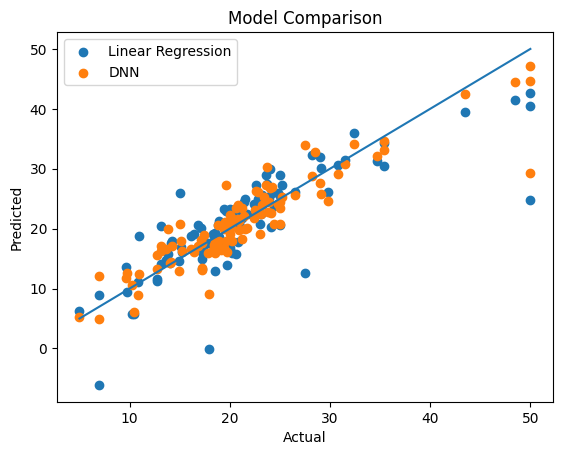

In [21]:
plt.scatter(y_test, lr_pred, label='Linear Regression')
plt.scatter(y_test, dnn_pred, label='DNN')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.legend()
plt.title("Model Comparison")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()